# EDA Project 1

Credit Card Customer Behavior Analysis

In [6]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sakshigoyal7/credit-card-customers")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'credit-card-customers' dataset.
Path to dataset files: /kaggle/input/credit-card-customers


In [7]:
# Getting the data
import pandas as pd
data = pd.read_csv('/kaggle/input/credit-card-customers/BankChurners.csv')

In [8]:
# Converting the data into pandas dataframe
df = pd.DataFrame(data)
df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


In [9]:
df.drop(columns=['CLIENTNUM', 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1', 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'], axis=1, inplace=True)

In [10]:
df.head()

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [11]:
print(df.columns)

Index(['Attrition_Flag', 'Customer_Age', 'Gender', 'Dependent_count',
       'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category',
       'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio'],
      dtype='object')


In [12]:
# renaming the columns
df.rename(columns={'Attrition_Flag': 'Customer_Status', 'Dependent_count': 'Num_Dependents', 'Months_on_book': 'Tenure_Months', 'Total_Relationship_Count': 'Relationship_Count', 'Months_Inactive_12_mon': 'Inactive_Months_Last_Year', 'Contacts_Count_12_mon': 'Num_Contacts_Last_Year', 'Avg_Open_To_Buy': 'Avg_Open_Credit', 'Total_Amt_Chng_Q4_Q1': 'Quarterly_Trans_Amt_Change', 'Total_Trans_Amt': 'Total_Transaction_Amount', 'Total_Trans_Ct': 'Total_Transaction_Count', 'Total_Ct_Chng_Q4_Q1': 'Quarterly_Trans_Count_Change'}, inplace=True)

In [13]:
df.head()

,Customer_Status,Customer_Age,Gender,Num_Dependents,Education_Level,Marital_Status,Income_Category,Card_Category,Tenure_Months,Relationship_Count,Inactive_Months_Last_Year,Num_Contacts_Last_Year,Credit_Limit,Total_Revolving_Bal,Avg_Open_Credit,Quarterly_Trans_Amt_Change,Total_Transaction_Amount,Total_Transaction_Count,Quarterly_Trans_Count_Change,Avg_Utilization_Ratio
0,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [14]:
# Checking the null values
df.isnull().sum()

,0
Customer_Status,0
Customer_Age,0
Gender,0
Num_Dependents,0
Education_Level,0
Marital_Status,0
Income_Category,0
Card_Category,0
Tenure_Months,0
Relationship_Count,0


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Customer_Status               10127 non-null  object 
 1   Customer_Age                  10127 non-null  int64  
 2   Gender                        10127 non-null  object 
 3   Num_Dependents                10127 non-null  int64  
 4   Education_Level               10127 non-null  object 
 5   Marital_Status                10127 non-null  object 
 6   Income_Category               10127 non-null  object 
 7   Card_Category                 10127 non-null  object 
 8   Tenure_Months                 10127 non-null  int64  
 9   Relationship_Count            10127 non-null  int64  
 10  Inactive_Months_Last_Year     10127 non-null  int64  
 11  Num_Contacts_Last_Year        10127 non-null  int64  
 12  Credit_Limit                  10127 non-null  float64
 13  T

In [16]:
# Checking the dataframe
df.describe()

,Customer_Age,Num_Dependents,Tenure_Months,Relationship_Count,Inactive_Months_Last_Year,Num_Contacts_Last_Year,Credit_Limit,Total_Revolving_Bal,Avg_Open_Credit,Quarterly_Trans_Amt_Change,Total_Transaction_Amount,Total_Transaction_Count,Quarterly_Trans_Count_Change,Avg_Utilization_Ratio
count,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,46.325960,2.346203,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894
std,8.016814,1.298908,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691
min,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000
25%,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000
50%,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000
75%,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000
max,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000


Customer Status Count

In [17]:
print(df['Customer_Status'].value_counts())

Customer_Status
Existing Customer    8500
Attrited Customer    1627
Name: count, dtype: int64


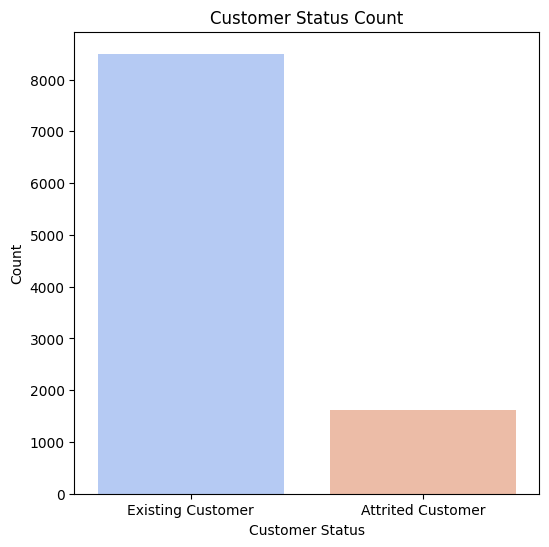

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 6))
sns.countplot(data=df, x='Customer_Status', hue='Customer_Status', palette='coolwarm')
plt.title("Customer Status Count")
plt.xlabel("Customer Status")
plt.ylabel("Count")
plt.show()

Distributions of Categorical Features:

Gender
F    5358
M    4769
Name: count, dtype: int64




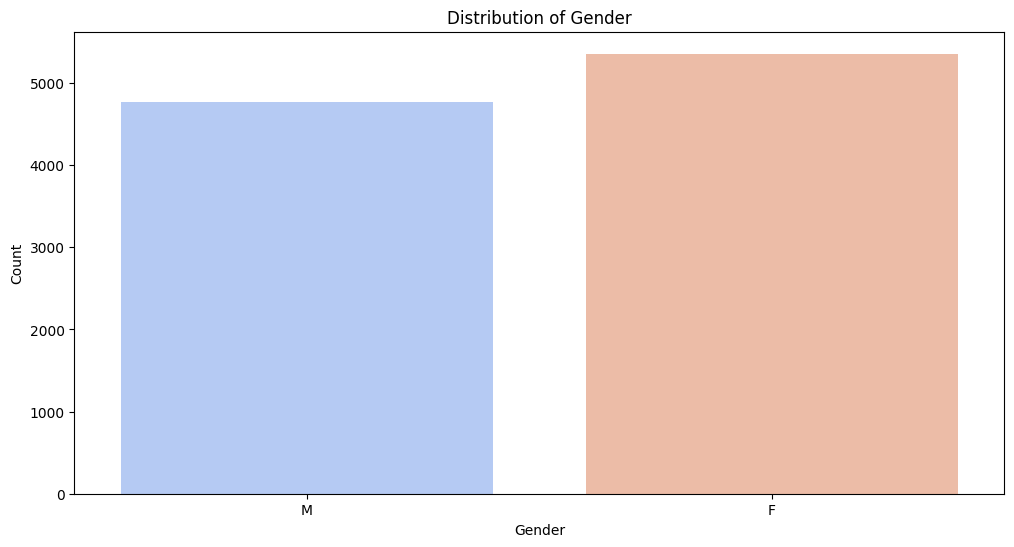



Education_Level
Graduate         3128
High School      2013
Unknown          1519
Uneducated       1487
College          1013
Post-Graduate     516
Doctorate         451
Name: count, dtype: int64




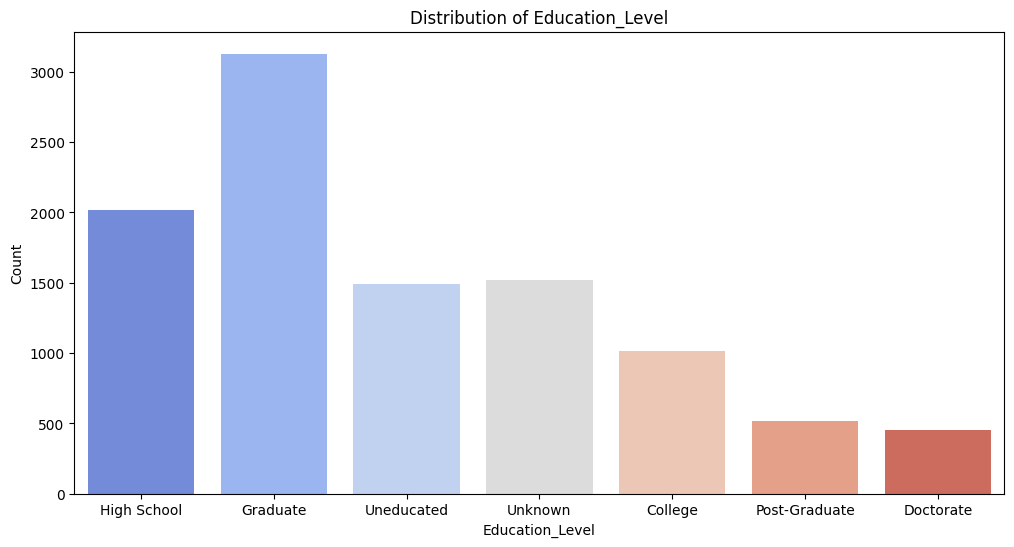



Marital_Status
Married     4687
Single      3943
Unknown      749
Divorced     748
Name: count, dtype: int64




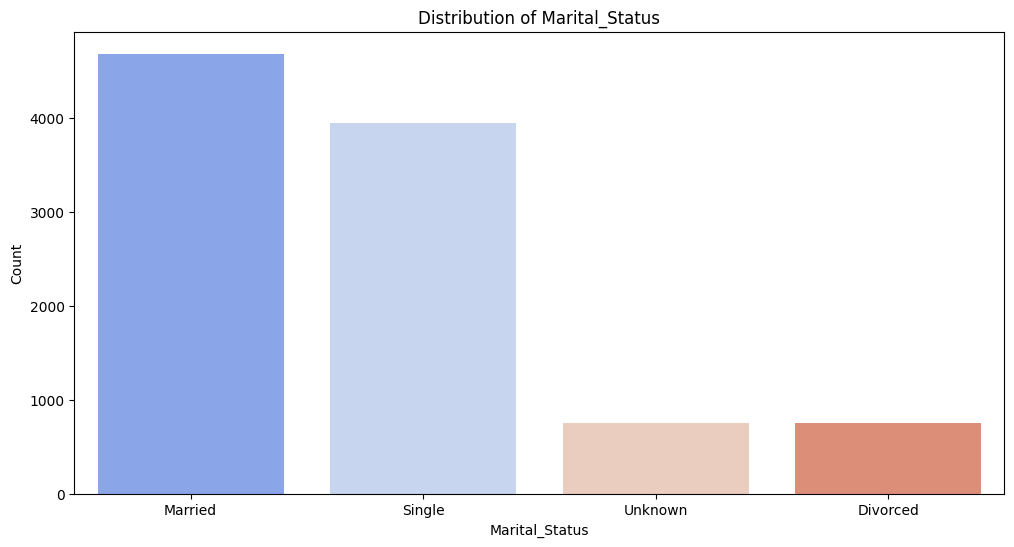



Income_Category
Less than $40K    3561
$40K - $60K       1790
$80K - $120K      1535
$60K - $80K       1402
Unknown           1112
$120K +            727
Name: count, dtype: int64




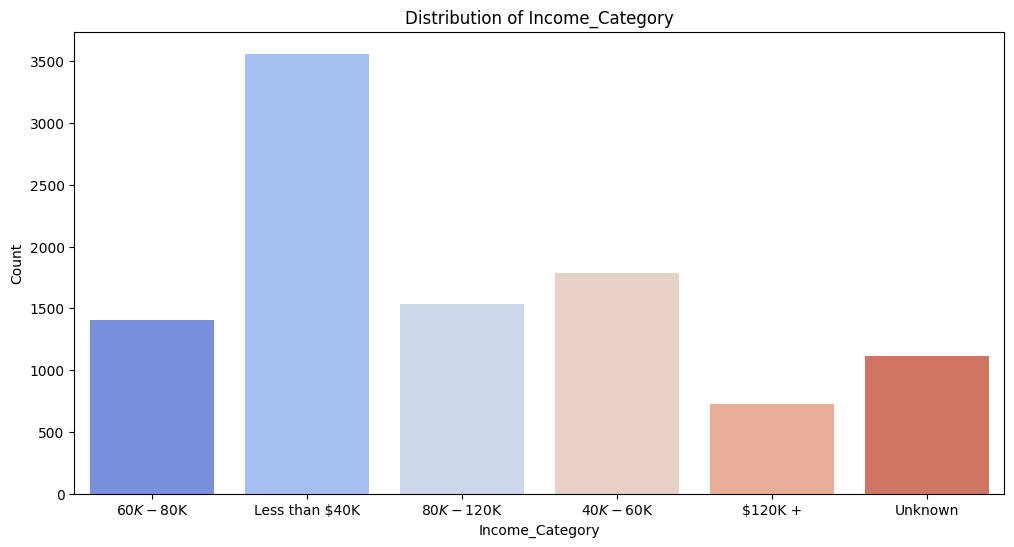



Card_Category
Blue        9436
Silver       555
Gold         116
Platinum      20
Name: count, dtype: int64




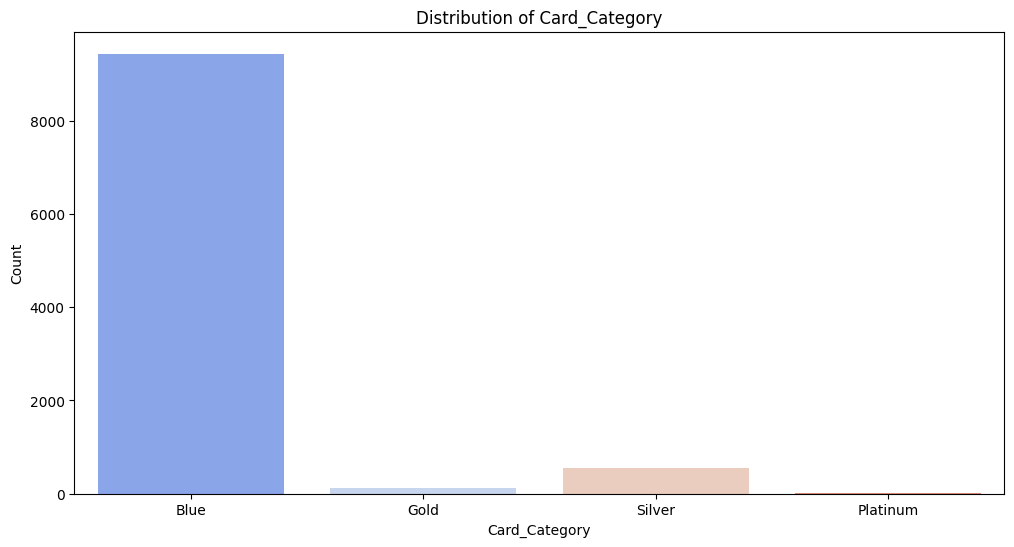

In [19]:
categorical_features = ['Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']

for feature in categorical_features:
  print(df[feature].value_counts())
  print("\n")
  plt.figure(figsize=(12,6))
  sns.countplot(data=df, x=feature, hue=feature, palette='coolwarm')
  plt.title(f'Distribution of {feature}')
  plt.xlabel(feature)
  plt.ylabel('Count')
  plt.show()
  print("\n")

Distributions of Numerical Features

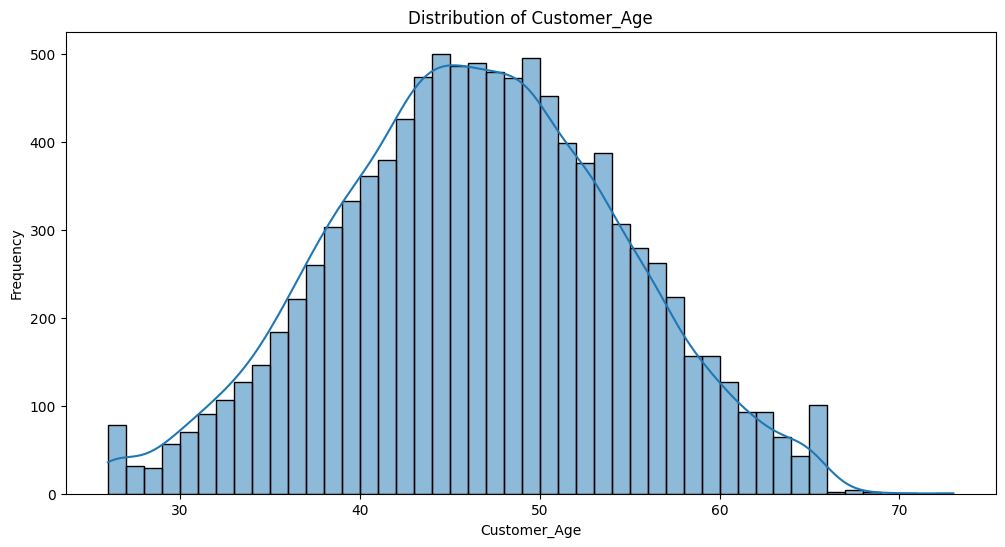

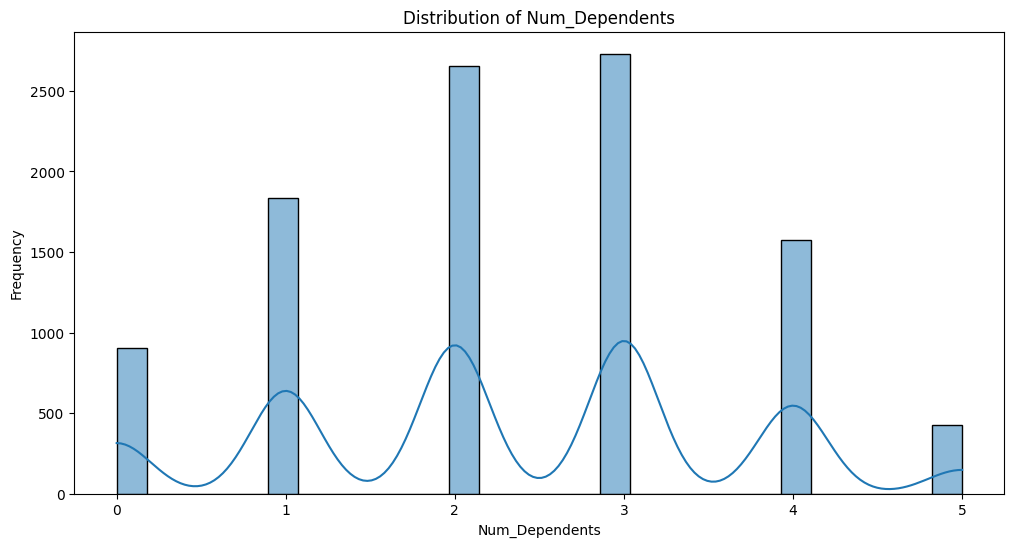

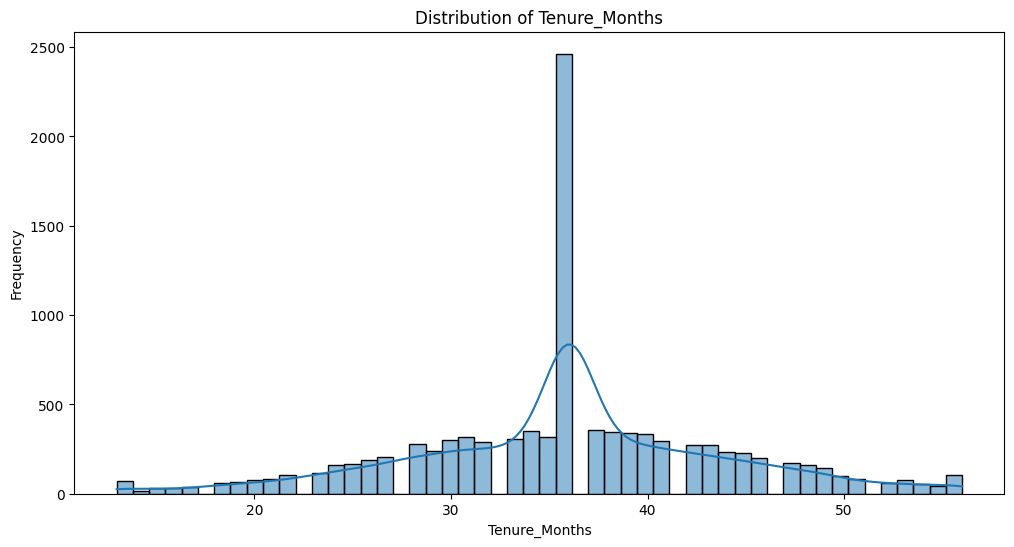

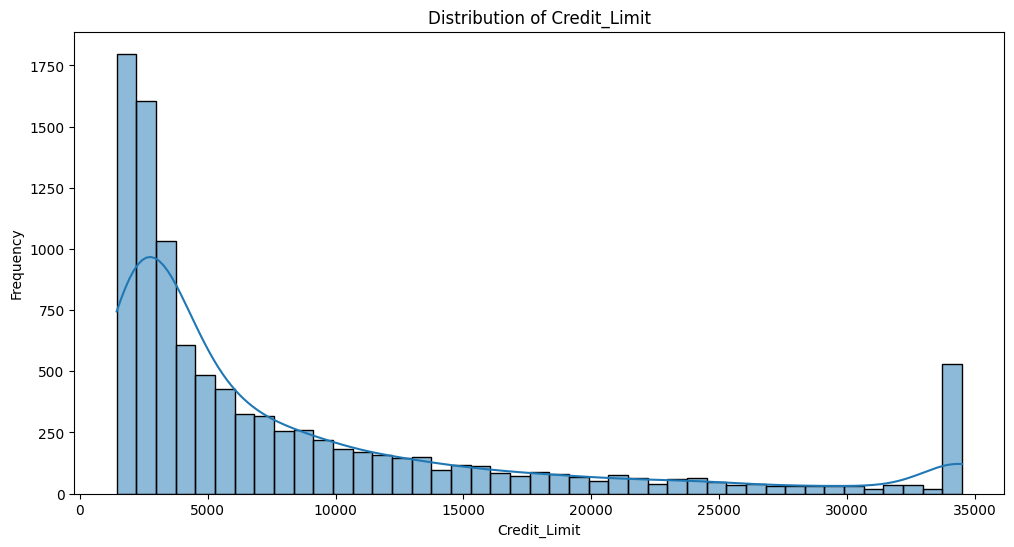

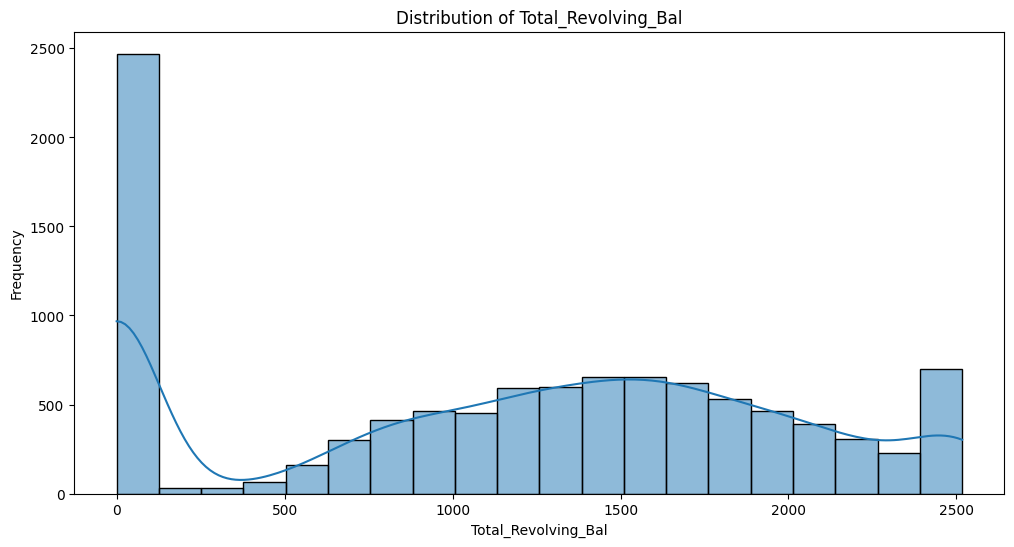

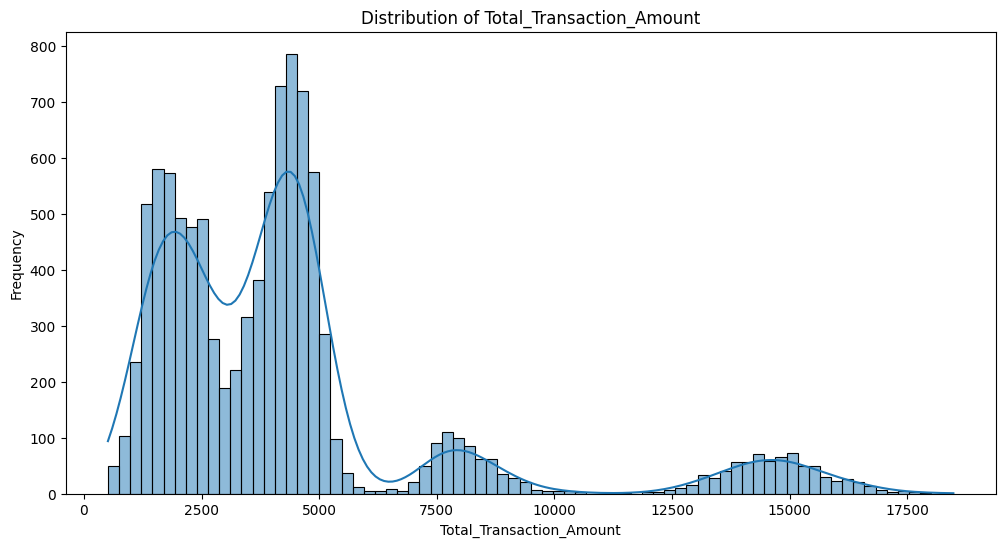

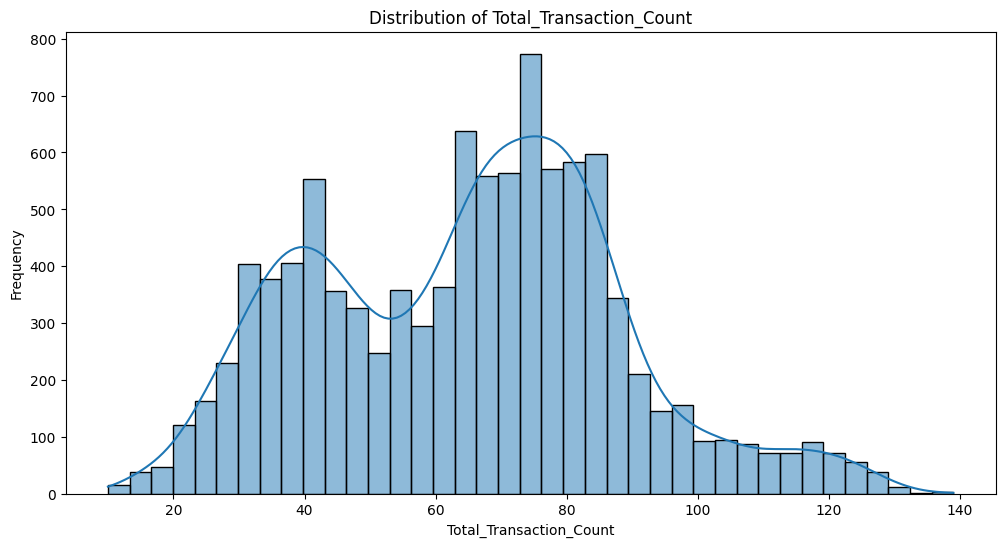

In [25]:
numerical_features = ['Customer_Age', 'Num_Dependents', 'Tenure_Months', 'Credit_Limit', 'Total_Revolving_Bal', 'Total_Transaction_Amount', 'Total_Transaction_Count']

for feature in numerical_features:
  plt.figure(figsize=(12,6))
  sns.histplot(df[feature], kde=True)
  plt.title(f'Distribution of {feature}')
  plt.xlabel(feature)
  plt.ylabel('Frequency')
  plt.show()
  print("\n")

Feature Comparisons Against Customer Status

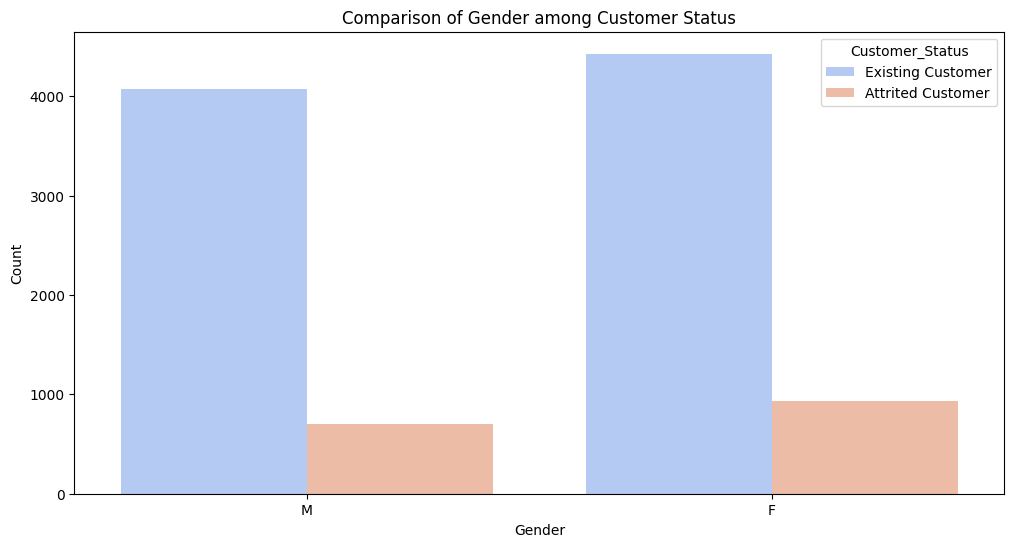

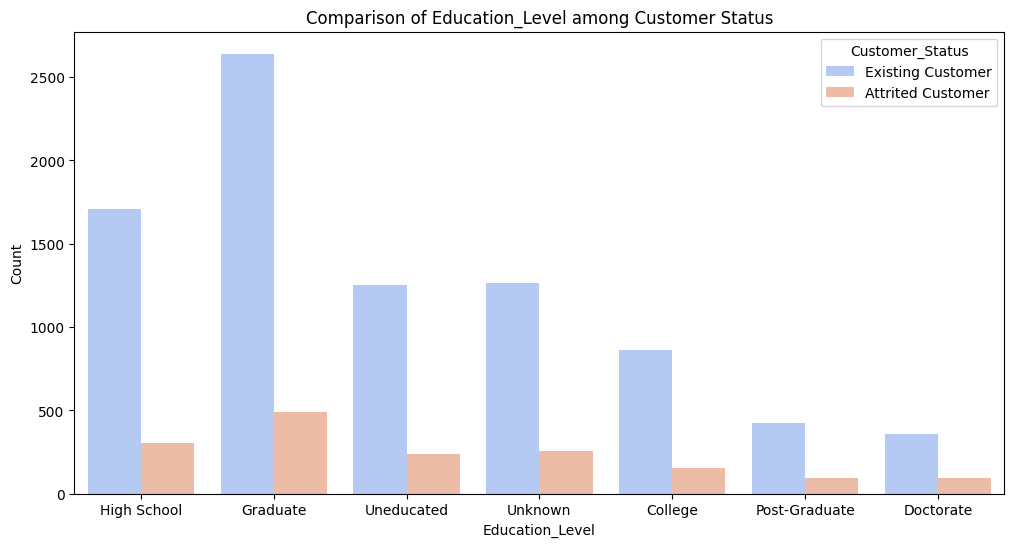

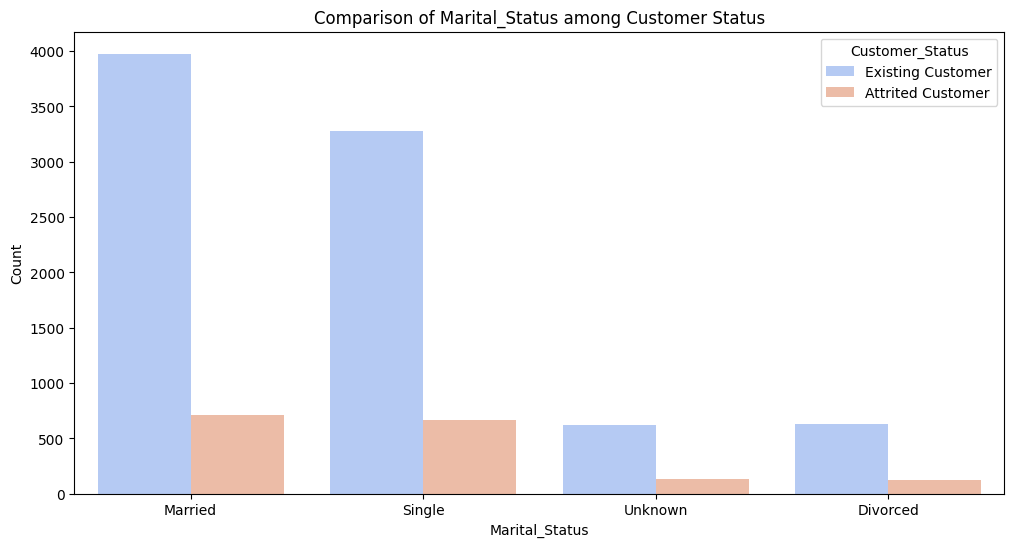

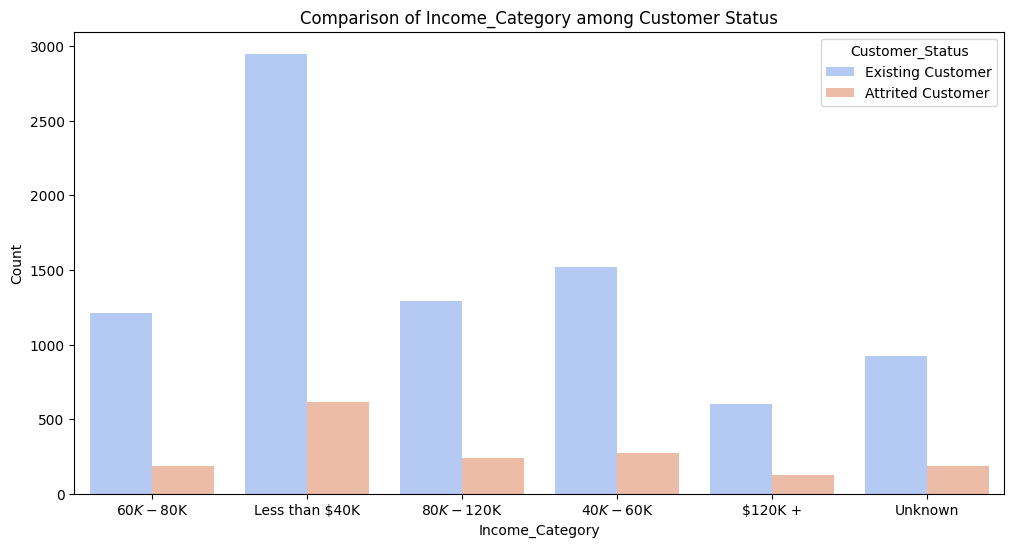

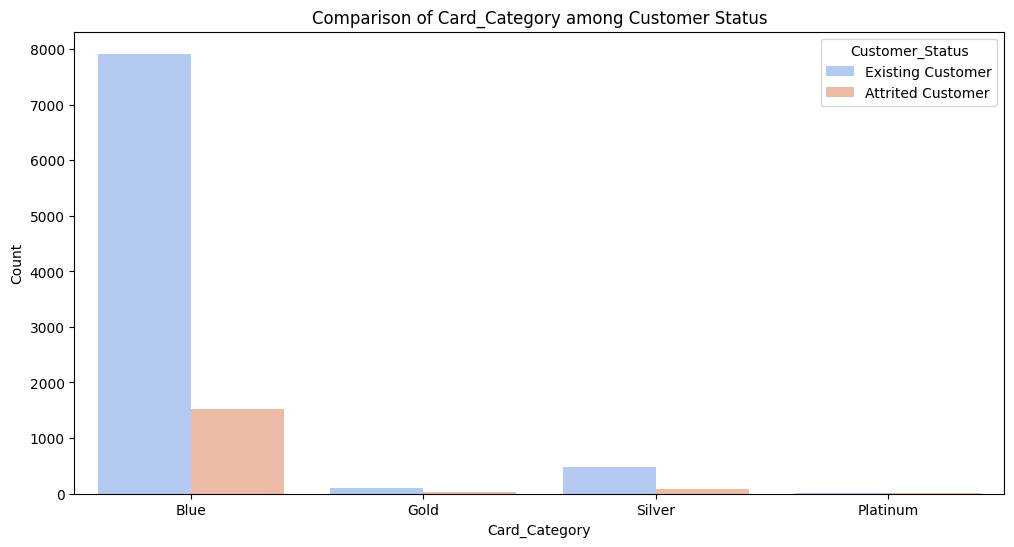

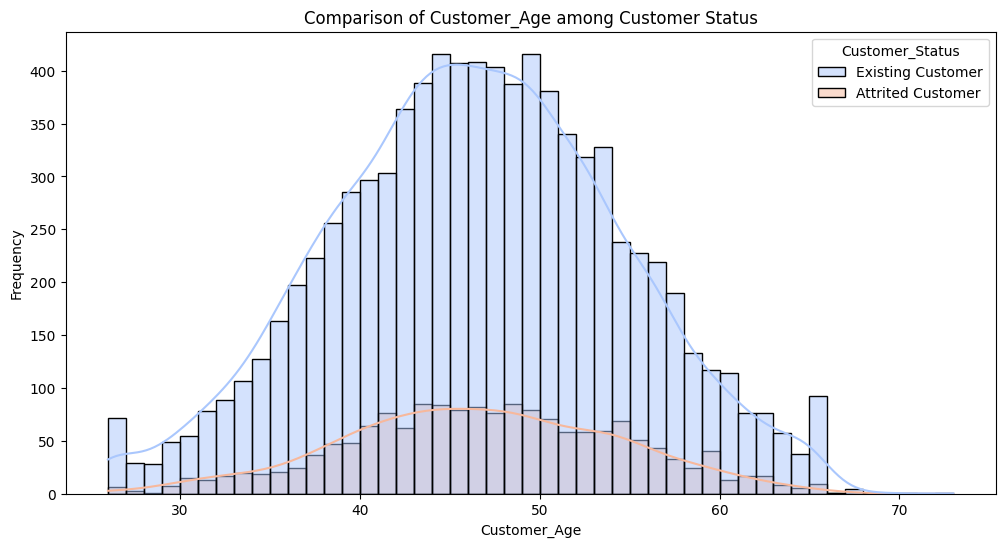

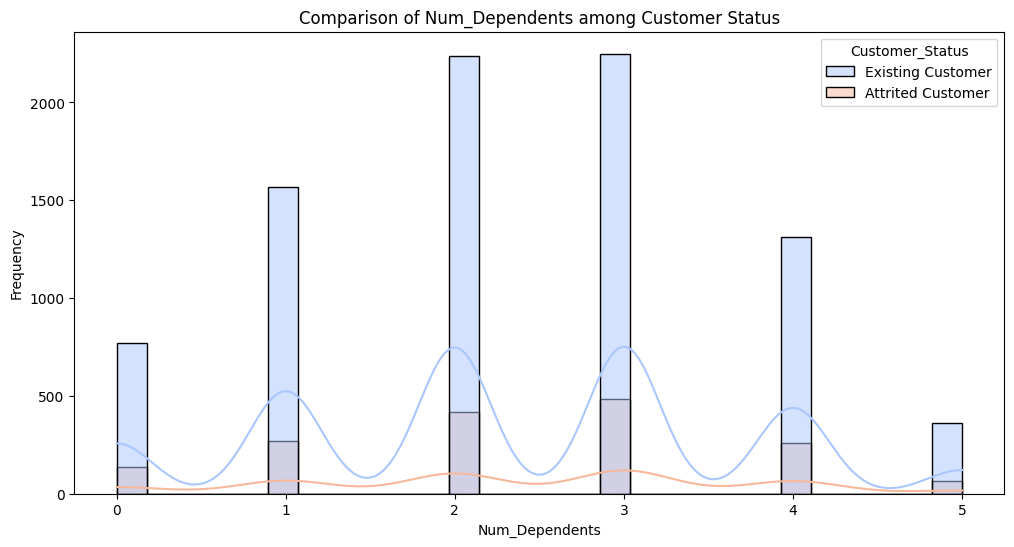

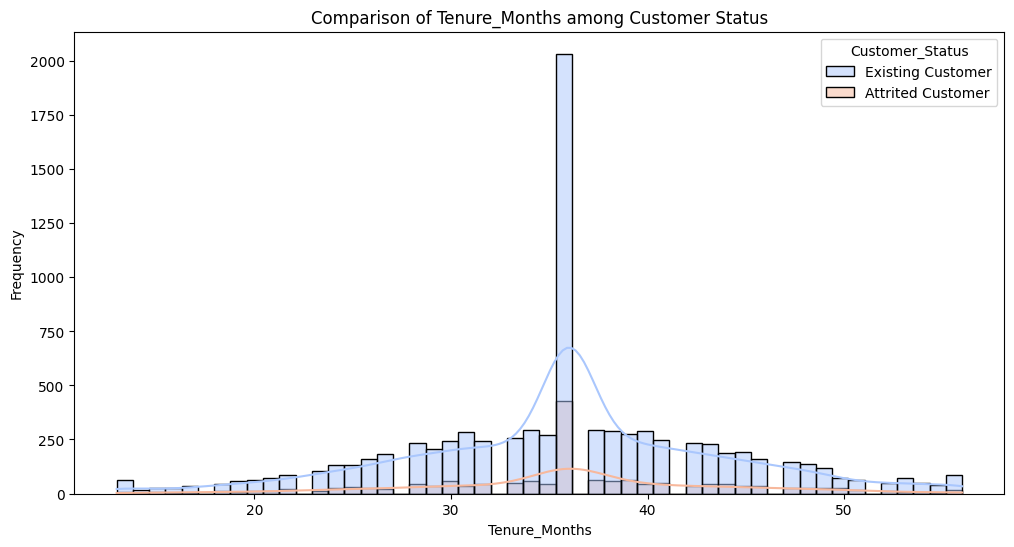

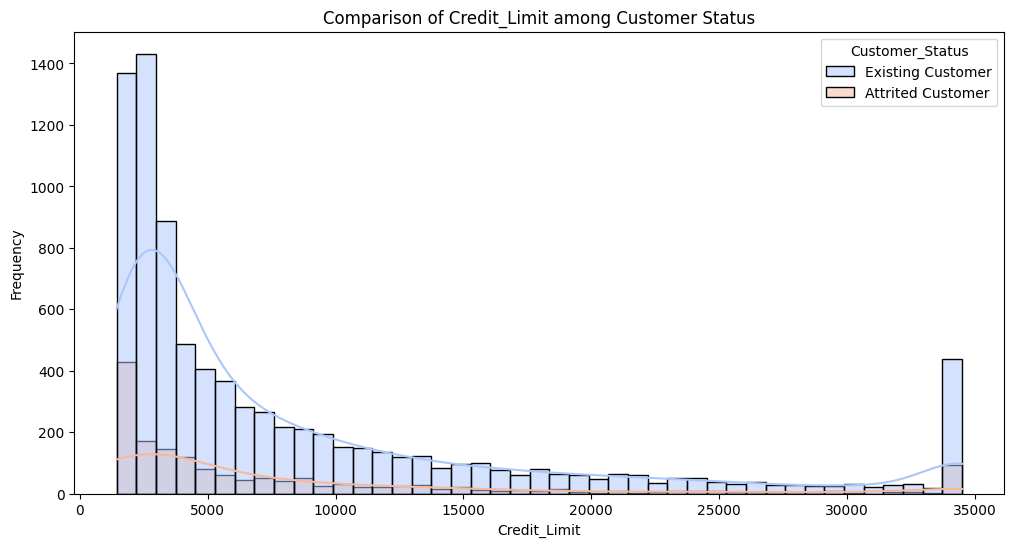

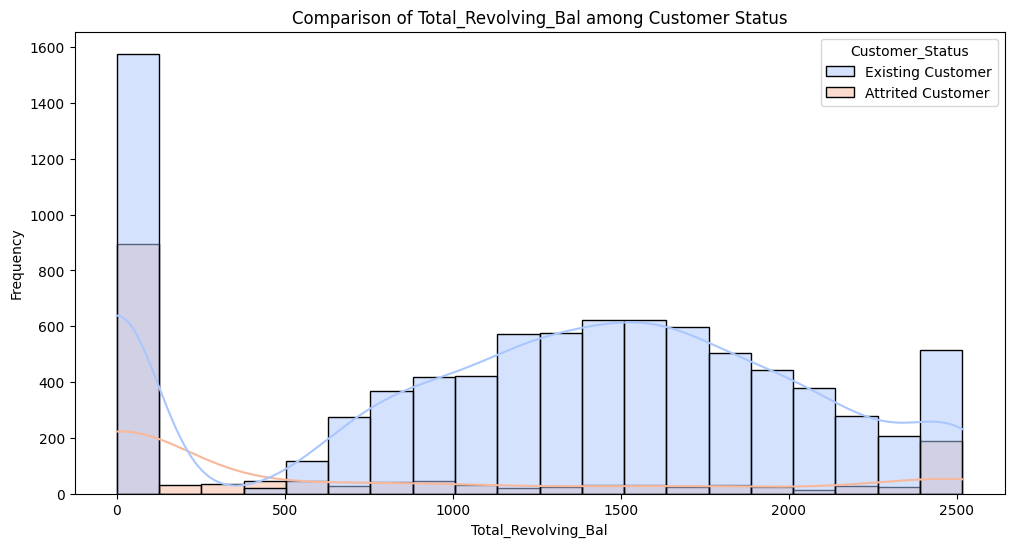

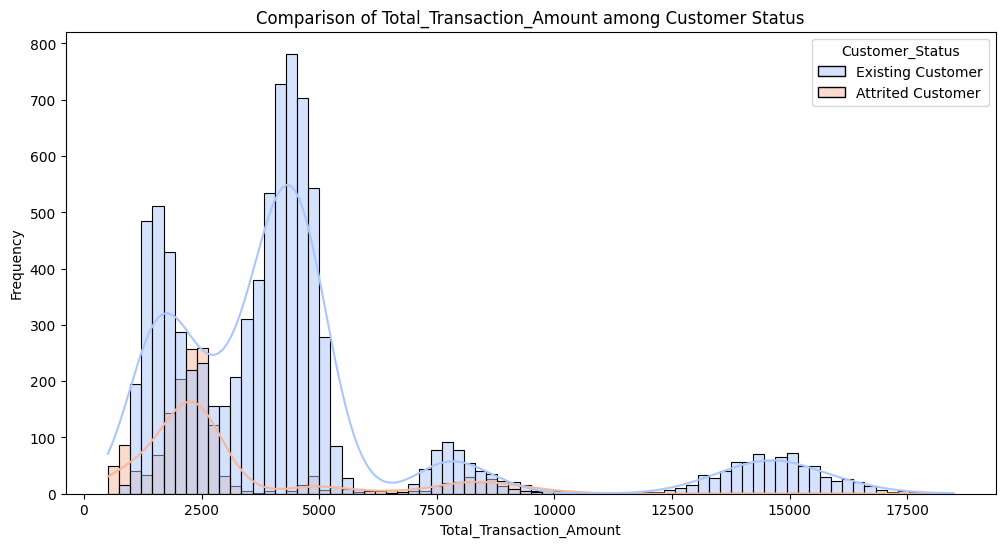

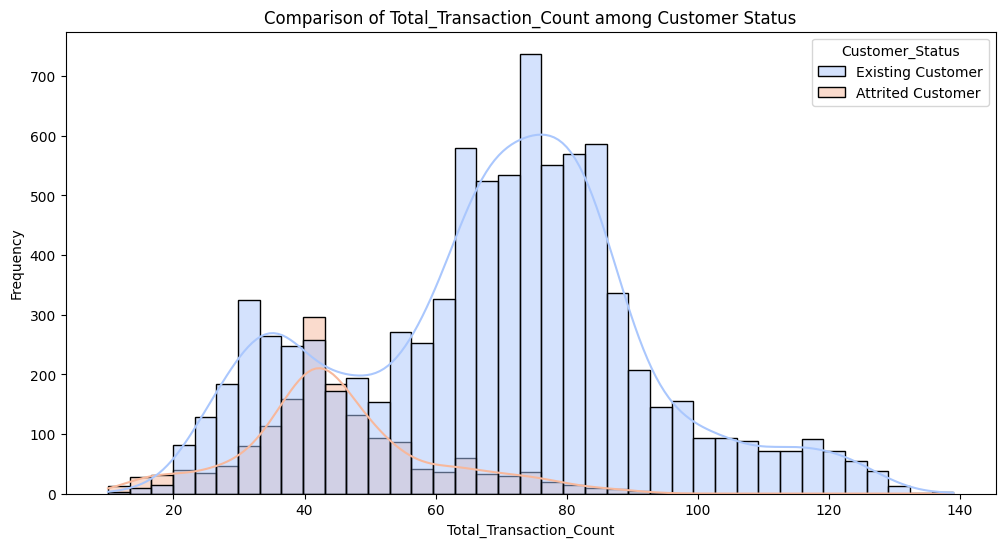

In [21]:
features = ['Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category', 'Customer_Age', 'Num_Dependents', 'Tenure_Months', 'Credit_Limit', 'Total_Revolving_Bal', 'Total_Transaction_Amount', 'Total_Transaction_Count']

for feature in features:
  if df[feature].dtype == 'object':
    plt.figure(figsize=(12,6))
    sns.countplot(data=df, x=feature, hue='Customer_Status', palette='coolwarm')
    plt.title(f'Comparison of {feature} among Customer Status')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.show()
    print("\n")
  else:
    plt.figure(figsize=(12,6))
    sns.histplot(data=df, x=feature, hue='Customer_Status', palette='coolwarm', kde=True)
    plt.title(f'Comparison of {feature} among Customer Status')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.show()
    print("\n")

Correlation Analysis

In [22]:
df.corr(numeric_only=True)

,Customer_Age,Num_Dependents,Tenure_Months,Relationship_Count,Inactive_Months_Last_Year,Num_Contacts_Last_Year,Credit_Limit,Total_Revolving_Bal,Avg_Open_Credit,Quarterly_Trans_Amt_Change,Total_Transaction_Amount,Total_Transaction_Count,Quarterly_Trans_Count_Change,Avg_Utilization_Ratio
Customer_Age,1.000000,-0.122254,0.788912,-0.010931,0.054361,-0.018452,0.002476,0.014780,0.001151,-0.062042,-0.046446,-0.067097,-0.012143,0.007114
Num_Dependents,-0.122254,1.000000,-0.103062,-0.039076,-0.010768,-0.040505,0.068065,-0.002688,0.068291,-0.035439,0.025046,0.049912,0.011087,-0.037135
Tenure_Months,0.788912,-0.103062,1.000000,-0.009203,0.074164,-0.010774,0.007507,0.008623,0.006732,-0.048959,-0.038591,-0.049819,-0.014072,-0.007541
Relationship_Count,-0.010931,-0.039076,-0.009203,1.000000,-0.003675,0.055203,-0.071386,0.013726,-0.072601,0.050119,-0.347229,-0.241891,0.040831,0.067663
Inactive_Months_Last_Year,0.054361,-0.010768,0.074164,-0.003675,1.000000,0.029493,-0.020394,-0.042210,-0.016605,-0.032247,-0.036982,-0.042787,-0.038989,-0.007503
Num_Contacts_Last_Year,-0.018452,-0.040505,-0.010774,0.055203,0.029493,1.000000,0.020817,-0.053913,0.025646,-0.024445,-0.112774,-0.152213,-0.094997,-0.055471
Credit_Limit,0.002476,0.068065,0.007507,-0.071386,-0.020394,0.020817,1.000000,0.042493,0.995981,0.012813,0.171730,0.075927,-0.002020,-0.482965
Total_Revolving_Bal,0.014780,-0.002688,0.008623,0.013726,-0.042210,-0.053913,0.042493,1.000000,-0.047167,0.058174,0.064370,0.056060,0.089861,0.624022
Avg_Open_Credit,0.001151,0.068291,0.006732,-0.072601,-0.016605,0.025646,0.995981,-0.047167,1.000000,0.007595,0.165923,0.070885,-0.010076,-0.538808
Quarterly_Trans_Amt_Change,-0.062042,-0.035439,-0.048959,0.050119,-0.032247,-0.024445,0.012813,0.058174,0.007595,1.000000,0.039678,0.005469,0.384189,0.035235


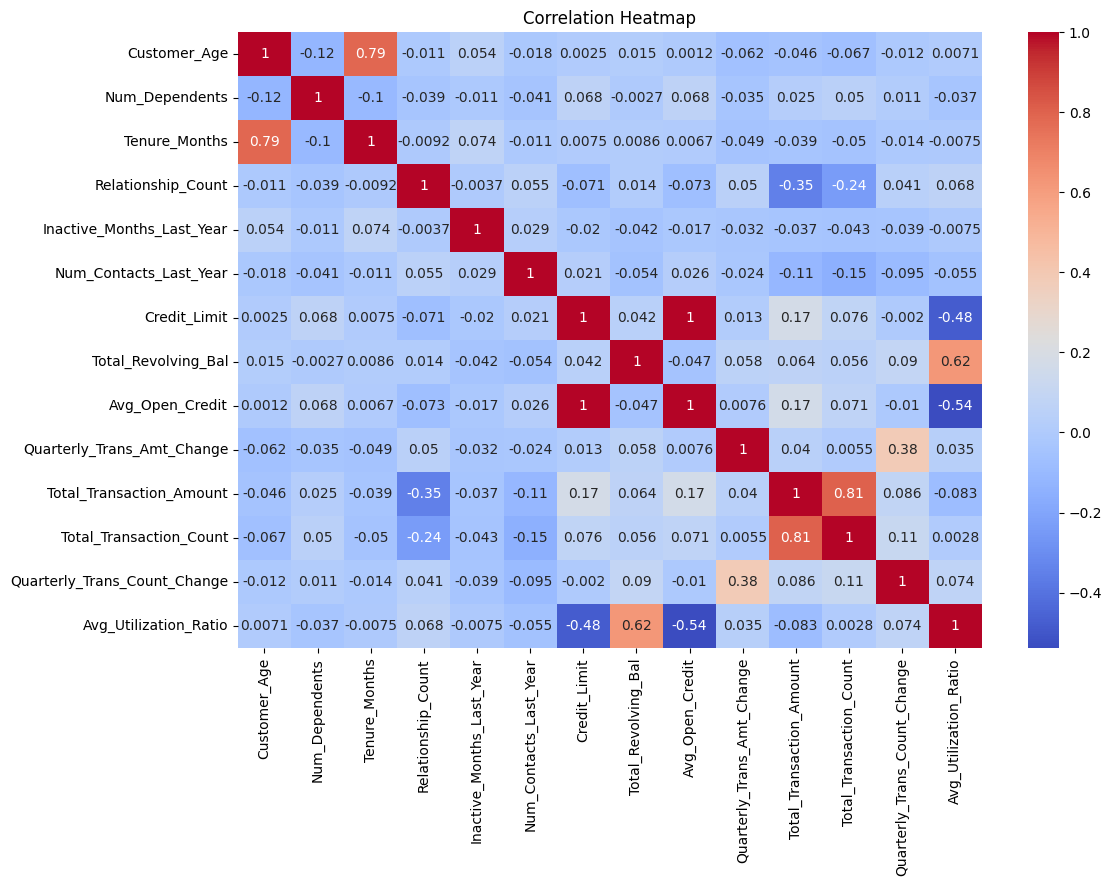

In [23]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## Insights from Exploratory Data Analysis

Based on the visualizations performed, here are the key insights into customer behavior:

### 1. Customer Status Overview

*   **Majority are Existing Customers**: The dataset is imbalanced, with a significantly larger proportion of existing customers (8500) compared to attrited customers (1627).

### 2. Categorical Feature Distributions

*   **Gender**: The customer base is relatively balanced between females (5358) and males (4769).
*   **Education Level**: 'Graduate' is the most common education level, followed by 'High School' and 'Unknown'. 'Doctorate' and 'Post-Graduate' are the least common.
*   **Marital Status**: 'Married' and 'Single' customers form the largest groups, with 'Unknown' and 'Divorced' being less frequent.
*   **Income Category**: The 'Less than $40K' income category is the most prevalent, followed by '$40K - $60K'. There's also a notable portion of 'Unknown' income.
*   **Card Category**: The vast majority of customers hold 'Blue' cards, with 'Silver', 'Gold', and 'Platinum' cards being much less common.

### 3. Numerical Feature Distributions

*   **Customer Age**: The distribution appears somewhat normal, centered around 45-50 years, with most customers between 30 and 60.
*   **Num Dependents**: The distribution is skewed, with 0 to 3 dependents being most common.
*   **Tenure Months**: The distribution is largely concentrated around 30-40 months, aligning with typical card lifecycle, but there's a wider range from 13 to 56 months.
*   **Credit Limit**: Highly skewed to the right, indicating many customers have lower credit limits, and a few have very high limits. This might suggest different tiers of customers.
*   **Total Revolving Bal**: Peaks around 0 and then around 1200-1800, suggesting a significant portion of customers either pay off their balance completely or carry a moderate balance.
*   **Total Transaction Amount**: Highly skewed to the right, with most transactions being lower amounts, and a long tail of higher transaction amounts.
*   **Total Transaction Count**: Also skewed to the right, indicating many customers have a lower number of transactions, with fewer customers having a very high number of transactions.

### 4. Feature Comparisons Against Customer Status

*   **Gender vs. Customer Status**: A higher proportion of female customers appear to be attrited compared to male customers, though both genders have more existing customers.
*   **Education Level vs. Customer Status**: Attrition seems somewhat distributed across education levels, with 'Unknown' education level having a higher proportion of attrited customers.
*   **Marital Status vs. Customer Status**: 'Single' customers might show a slightly higher attrition rate compared to 'Married' customers.
*   **Income Category vs. Customer Status**: Customers in the 'Less than $40K' and 'Unknown' income categories might have a higher likelihood of attrition.
*   **Card Category vs. Customer Status**: 'Blue' cardholders, being the most numerous, also have the highest absolute number of attrited customers. However, it would be useful to look at *proportions* within each card category to see if higher-tier cards have lower attrition rates.
*   **Customer Age vs. Customer Status**: The age distributions for existing and attrited customers appear similar, suggesting age alone might not be a strong predictor of attrition.
*   **Num Dependents vs. Customer Status**: No significant difference observed in the distribution of dependents between existing and attrited customers.
*   **Tenure Months vs. Customer Status**: Similar to age, tenure months do not show a dramatically different distribution between existing and attrited customers.
*   **Credit Limit vs. Customer Status**: Attrited customers seem to have generally lower credit limits compared to existing customers, where the distribution extends to much higher limits.
*   **Total Revolving Bal vs. Customer Status**: Attrited customers tend to have lower revolving balances, with a larger peak at zero or very low balances, implying they might not be utilizing their credit as much.
*   **Total Transaction Amount vs. Customer Status**: Attrited customers show significantly lower total transaction amounts compared to existing customers, which have a much wider and higher range of transaction amounts.
*   **Total Transaction Count vs. Customer Status**: Similar to transaction amount, attrited customers have a lower total transaction count, indicating less active engagement.

### 5. Correlation Analysis

*   **Strong Positive Correlations**:
    *   `Customer_Age` and `Tenure_Months` (0.78): As expected, older customers tend to have been with the bank longer.
    *   `Credit_Limit` and `Avg_Open_Credit` (0.99): These two are almost perfectly correlated, which is logical as `Avg_Open_Credit` is `Credit_Limit - Total_Revolving_Bal`.
    *   `Total_Transaction_Amount` and `Total_Transaction_Count` (0.80): Customers who transact more frequently also tend to have higher total transaction amounts.
*   **Moderate Positive Correlations**:
    *   `Total_Revolving_Bal` and `Avg_Utilization_Ratio` (0.62): Higher revolving balance leads to higher utilization.
*   **Moderate Negative Correlations**:
    *   `Credit_Limit` and `Avg_Utilization_Ratio` (-0.48): Customers with higher credit limits tend to have lower utilization ratios, possibly because their limit is high relative to their spending.
    *   `Avg_Open_Credit` and `Avg_Utilization_Ratio` (-0.53):
*   **Weak/No Correlations**: Many other features show weak or negligible correlations, implying they are relatively independent of each other.

### Key Takeaways for Attrition:

*   **Engagement Metrics are Crucial**: `Total_Transaction_Amount`, `Total_Transaction_Count`, `Total_Revolving_Bal` are significantly lower for attrited customers, highlighting that less active and less engaged customers are more likely to churn.
*   **Credit Limit Matters**: Lower `Credit_Limit` might be associated with higher attrition.
*   **Demographic Differences**: Some differences are observed across `Gender`, `Marital_Status`, and `Income_Category` but these might be less impactful than engagement metrics.
